<a href="https://colab.research.google.com/github/nicolasDavalos/sis420_IA_Davalos_Alvarez_Nicolas_Darko/blob/main/sis420_lab01_davalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importacion de librerias

In [ ]:
  # utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

Conección con Google drive

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


Aquí se cargan las variables del dataset, con drop separamos las celdas que contenían valores literarios y no numéricos, además dividimos las variables independientes de la dependiente

In [ ]:
# Librería para manejo de datos
import pandas as pd
import numpy as np

# Cargar datos desde Google Drive
data = pd.read_csv('/content/gdrive/MyDrive/IA/smoking_driking_dataset_Ver01.csv/smoking_driking_dataset_Ver01.csv')

# Eliminar columnas no numéricas
data = data.drop(columns=['sex', 'DRK_YN'])

# Variable dependiente (lo que queremos predecir)
y = data['triglyceride'].values

# Variables independientes (todas las demás)
X = data.drop(columns=['triglyceride']).values

# Número de ejemplos
m = y.size

print("Número de ejemplos:", m)

# Mostrar dimensiones del dataset
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nPrimeros 10 ejemplos del dataset:\n")

# Mostrar primeras 10 filas completas
print(data.head(10))

Número de ejemplos: 991346
Dimensión de X: (991346, 21)
Dimensión de y: (991346,)

Primeros 10 ejemplos del dataset:

   age  height  weight  waistline  sight_left  sight_right  hear_left  \
0   35     170      75       90.0         1.0          1.0        1.0   
1   30     180      80       89.0         0.9          1.2        1.0   
2   40     165      75       91.0         1.2          1.5        1.0   
3   50     175      80       91.0         1.5          1.2        1.0   
4   50     165      60       80.0         1.0          1.2        1.0   
5   50     165      55       75.0         1.2          1.5        1.0   
6   45     150      55       69.0         0.5          0.4        1.0   
7   35     175      65       84.2         1.2          1.0        1.0   
8   55     170      75       84.0         1.2          0.9        1.0   
9   40     175      75       82.0         1.5          1.5        1.0   

   hear_right    SBP    DBP  ...  HDL_chole  LDL_chole  triglyceride  \
0     

Normalizados las variables para que tengan un rango más cercano y hacemos una copia del los datos del dataset para modificar eso y no los datos del dataset original

In [ ]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

usa la funcion antes definida y luego muestra los resultados para asegurarse que todo este en orden

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X[:5])
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm[:5])

[[ 35.  170.   75.   90.    1.    1.    1.    1.  120.   80.   99.  193.
   48.  126.   17.1   1.    1.   21.   35.   40.    1. ]
 [ 30.  180.   80.   89.    0.9   1.2   1.    1.  130.   82.  106.  228.
   55.  148.   15.8   1.    0.9  20.   36.   27.    3. ]
 [ 40.  165.   75.   91.    1.2   1.5   1.    1.  120.   70.   98.  136.
   41.   74.   15.8   1.    0.9  47.   32.   68.    1. ]
 [ 50.  175.   80.   91.    1.5   1.2   1.    1.  145.   87.   95.  201.
   76.  104.   17.6   1.    1.1  29.   34.   18.    1. ]
 [ 50.  165.   60.   80.    1.    1.2   1.    1.  138.   82.  101.  199.
   61.  117.   13.8   1.    0.8  19.   12.   25.    1. ]]
Media calculada: [ 47.6144908  162.24062537  63.28405017  81.23335778   0.98083434
   0.97842913   1.03149455   1.03047574 122.43249784  76.05262744
 100.42444717 195.55702046  56.93680007 113.03769219  14.22982369
   1.09422442   0.86046668  25.98930848  25.75505121  37.13634695
   1.60812169]
Desviación estandar calculada: [14.18133193  9.282952

añade la columna de bias o 1 que representara x0
(para poder aplicar la funcion en la matriz) O mejor dicho unir las dos ecuaciones matemáticas en una sola

In [ ]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

Tomamos algunos de los primeros ejemplos, imprimimos y vemos que se aplicó la columna de 1 de forma correcta

In [ ]:
print(X[:5])

[[ 1.         -0.88951382  0.83587354  0.93620986  0.73978124  0.0316292
   0.03566767 -0.18032947 -0.17729552 -0.16726083  0.39915348 -0.05891027
  -0.06614101 -0.51842187  0.36164334  1.81091911 -0.21526022  0.29037369
  -0.21237088  0.35140424  0.05679133 -0.74296486]
 [ 1.         -1.24209002  1.91311698  1.33575488  0.65539531 -0.13340138
   0.36636983 -0.18032947 -0.17729552  0.52034855  0.60139102  0.23058581
   0.83918433 -0.11235336  0.97543478  0.99069255 -0.21526022  0.08227022
  -0.25493607  0.38941465 -0.20102176  1.70050947]
 [ 1.         -0.53693763  0.29725182  0.93620986  0.82416716  0.36169035
   0.86242306 -0.18032947 -0.17729552 -0.16726083 -0.61203427 -0.10026685
  -1.54052799 -0.92449039 -1.08913642  0.99069255 -0.21526022  0.08227022
   0.89432413  0.23737303  0.61208106 -0.74296486]
 [ 1.          0.16821475  1.37449526  1.33575488  0.82416716  0.85678207
   0.36636983 -0.18032947 -0.17729552  1.55176263  1.10698489 -0.2243366
   0.14079049  1.10585218 -0.252148

DESDE AQUI EMPIEZA DESCENSO POR GRADIENTE

define la funcion de costo para la regresión multivariable

In [ ]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

implementa el algoritmo de descenso por gradiente, es donde se ajustan los parametros para minimizar el error

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

COEFICIENTES DE APRENDIZAJE

muestra cómo converge el error y usa el modelo para predecir un precio

Theta calculado por el descenso por el gradiente:
[ 1.14437442e+02  1.49042662e+00 -2.48131349e+00  7.44690040e+00
  5.77815778e+00 -2.55569089e-02  8.08100749e-02 -2.77669194e-01
 -2.43798757e-01  3.06624859e+00  4.22017977e+00  9.77486404e+00
  2.88766309e+01 -1.91182041e+01 -1.42823435e+01  5.59805463e+00
  1.06051334e+00  1.87922445e-02 -4.28841641e-01  3.36872179e+00
  1.55341199e+01  7.18006319e+00]
Predicción de triglicéridos:
112.26058846674039


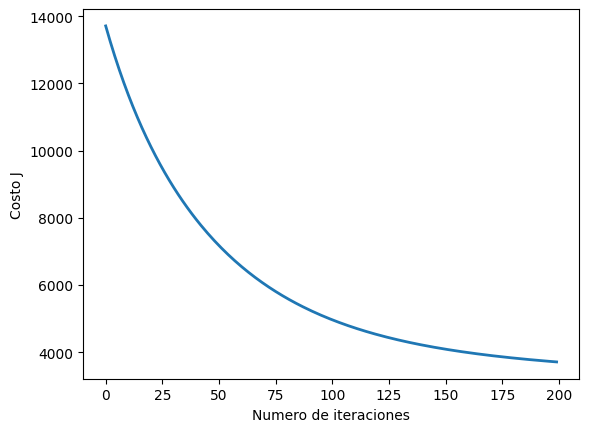

In [ ]:
# Elegir algun valor para alpha
alpha = 0.01
num_iters = 200

# inicializa theta
theta = np.zeros(X.shape[1])

# ejecutar descenso por gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Mostrar parámetros
print('Theta calculado por el descenso por el gradiente:')
print(theta)

# -------------------------------
# EJEMPLO DE PREDICCIÓN
# -------------------------------

# valores ejemplo
X_example = np.array([
45,   # age
170,  # height
75,   # weight
85,   # waistline
1.0,  # sight_left
1.0,  # sight_right
1,    # hear_left
1,    # hear_right
120,  # SBP
80,   # DBP
95,   # BLDS
190,  # tot_chole
55,   # HDL
120,  # LDL
15,   # hemoglobin
1,    # urine_protein
1.0,  # serum_creatinine
25,   # SGOT_AST
30,   # SGOT_ALT
35,   # gamma_GTP
1     # SMK_stat_type_cd
])

# normalizar (solo variables reales)
X_example_norm = (X_example - mu) / sigma

# añadir termino de intersección
X_example_final = np.concatenate(([1], X_example_norm))

# predicción
pred_triglycerides = np.dot(X_example_final, theta)

print("Predicción de triglicéridos:")
print(pred_triglycerides)

ecuacion de la normal

ecuación de la normal, otro metodo o forma de calcula la regresión lineal del modelo, carga el dataset, separa las variables de las independientes y de la objetivo, agrega la columna de 1 para x0, y ahora usa el etodo matematico de la ecuacion de la normal, este método calcula directamente theta

In [ ]:
# Librerías
import pandas as pd
import numpy as np

# Cargar dataset
data2 = pd.read_csv('/content/gdrive/MyDrive/IA/smoking_driking_dataset_Ver01.csv/smoking_driking_dataset_Ver01.csv')

# Tomar 30000 filas aleatorias
data2 = data2.sample(n=30000, random_state=42)

# Variable dependiente (lo que queremos predecir)
y2 = data2['triglyceride'].values

# Variables independientes (quitando columnas que no se usan)
X2 = data2.drop(columns=['triglyceride','sex','DRK_YN']).values

# Número de ejemplos
m2 = y2.size
print("Número de ejemplos usados:", m2)

# Añadir columna de intersección
X2 = np.concatenate([np.ones((m2, 1)), X2], axis=1)

print("Shape de X:", X2.shape)

Número de ejemplos usados: 30000
Shape de X: (30000, 22)


esta es la función de theta, hace todos los calculos con las funciones prefabricadas de phyton

In [ ]:
def normalEqn(X, y):
    # Usar pseudo-inversa para estabilidad y rapidez
    theta = np.linalg.pinv(X) @ y
    return theta

mostrara los resultados de theta obtenidos con la funcion de la normal, usa un ejemplo y calcula la prediccion del array de ejemplo

In [ ]:
# Calcula los parámetros con ecuación normal
theta = normalEqn(X2, y2)

# Mostrar parámetros
print('Theta calculado a partir de la ecuación de la normal:')
print(theta)
print("Cantidad de parámetros en theta:", len(theta))

# -----------------------------
# EJEMPLO DE PREDICCIÓN
# -----------------------------

X_array = np.array([
1,      # término de intersección
45,     # age
170,    # height
75,     # weight
85,     # waistline
1.0,    # sight_left
1.0,    # sight_right
1,      # hear_left
1,      # hear_right
120,    # SBP
80,     # DBP
95,     # BLDS
190,    # tot_chole
55,     # HDL_chole
120,    # LDL_chole
15,     # hemoglobin
1,      # urine_protein
1.0,    # serum_creatinine
25,     # SGOT_AST
30,     # SGOT_ALT
35,     # gamma_GTP
1       # SMK_stat_type_cd
])

# predicción
pred = np.dot(X_array, theta)

print("Predicción de triglicéridos con ecuación normal:")
print(pred)

Theta calculado a partir de la ecuación de la normal:
[-4.36104602e+01 -1.33190321e-01 -2.15976680e-01  3.54745230e-01
  1.23866349e-01  6.87369554e-01 -3.56981855e-01 -5.93335512e-01
 -4.36663498e-01  1.27738222e-01  8.58742776e-02  2.29542465e-01
  3.52035158e+00 -3.73581432e+00 -3.24054207e+00  1.13117492e+00
  2.15461474e+00 -5.71374157e-01 -3.37220780e-02  6.08283893e-03
  1.84597853e-01  4.24862763e+00]
Cantidad de parámetros en theta: 22
Predicción de triglicéridos con ecuación normal:
97.25173864115916
